# Часть 1

## Этап 1

### Импорты библиотек

Сначала импортируем библиотеки, необходимые для работы над проектом.

In [1]:
# импортируем базовые библиотеки для работы с данными
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# импортируем статистические инструменты
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# импортируем инструменты для подготовки данных
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# импортируем базовые алгоритмы машинного обучения
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# импортируем uplift-модели
from causalml.inference.meta import (
    BaseSClassifier,
    BaseTClassifier,
    BaseXClassifier,
    BaseRClassifier,
)
from causalml.inference.tree import UpliftRandomForestClassifier

# импортируем метрики для оценки uplift-моделей
from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    uplift_at_k,
)

# импортируем инструменты для подбора гиперпараметров
import optuna

# импортируем MLflow для логирования экспериментов
import mlflow

# импортируем вспомогательные функции проекта
import utils

# импортируем инструменты для работы с предупреждениями
import warnings

# импортируем progress bar для длительных вычислений
from tqdm.auto import tqdm

Также сразу зададим общие параметры для воспроизводимости результатов и настроим более читабельное отображение числовых значений в таблицах.

In [2]:
# задаём random state для воспроизводимости результатов
RANDOM_STATE = 42

# настраиваем отображение чисел с тремя знаками после запятой
pd.set_option("display.float_format", "{:,.3f}".format)

# настраиваем отображение всех столбцов в таблицах
pd.set_option("display.max_columns", None)

Необходимые библиотеки успешно импортированы, а также заданы параметры воспроизводимости и формат дальнейшего отображения данных. Таким образом, окружение готово для дальнейшей работы с данными, построения uplift-моделей, подбора гиперпараметров и логирования экспериментов в MLflow.

### Загрузка данных

Теперь задаём путь к исходным данным, проверяем существование файла и загружаем датасет для дальнейшего анализа.

In [3]:
# задаём путь к исходному датасету
DATA_PATH = Path("uplift_fp_data.csv")

In [4]:
# проверяем существование файла с данными
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Файл не найден: {DATA_PATH.resolve()}")

# загружаем датасет и делаем проверку
data = pd.read_csv(DATA_PATH)
data.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.440,1,0,1,0,1,1,0
1,6,2,329.080,1,1,2,1,2,0,0
2,7,1,180.650,0,1,1,1,2,1,0
3,9,4,675.830,1,0,2,1,2,0,0
4,2,0,45.340,1,0,0,0,2,1,0


Датасет успешно загружен. В данных представлены признаки поведения и характеристик клиентов, индикатор воздействия `treatment` и целевая переменная `target`.

### Первичное знакомство с данными

Проверим размер датасета, типы данных, количество пропусков и дубликатов, чтобы оценить качество исходных данных перед дальнейшим анализом.

In [6]:
# создаём функцию, позволяющую произвести быстрое знакомство с данными
def explo_data(df: pd.DataFrame, n: int = 5):
    """
    Быстрый обзор датафрейма: head, размеры, столбцы, типы, пропуски, дубликаты, статистика.
    Параметры:
        - df (pd.DataFrame): датафрейм для анализа
        - n (int): сколько строк показывать в выборках (по умолчанию = 5)
    Пример:
        explo_data(train_df, n=10)
    """

    print("-" * 110)
    print("Первые строки:")
    display(df.head(n))

    print("-" * 110)
    print("Размеры датафрейма:")
    print(f"Строк: {df.shape[0]:,} | Столбцов: {df.shape[1]}")

    print("-" * 110)
    print("Названия столбцов:")
    print(list(df.columns))

    print("-" * 110)
    print("Информация о датафрейме:")
    df.info()

    print("-" * 110)
    print("Пропущенные значения (кол-во и %, отсортировано по убыванию):")
    missing_data = (
        df.isna()
        .sum()
        .to_frame(name="count")
        .assign(percent=lambda x: (x["count"] / len(df) * 100).round(2))
        .sort_values(by="count", ascending=False)
    )
    display(missing_data)

    print("-" * 110)
    print("Строки с пропущенными значениями (первые n строк):")
    display(df[df.isna().any(axis=1)].head(n))

    print("-" * 110)
    print("Явные дубликаты:")
    print(f"Количество дубликатов: {df.duplicated().sum():,}")

    print("-" * 110)
    print("Строки с явными дубликатами (первые n строк):")
    display(df[df.duplicated()].head(n))

    print("-" * 110)
    print("Описательная статистика:")
    display(df.describe(include="all"))

    print("-" * 110)

In [7]:
# выполняем первичную проверку качества данных с помощью созданной функции
explo_data(data)

--------------------------------------------------------------------------------------------------------------
Первые строки:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.440,1,0,1,0,1,1,0
1,6,2,329.080,1,1,2,1,2,0,0
2,7,1,180.650,0,1,1,1,2,1,0
3,9,4,675.830,1,0,2,1,2,0,0
4,2,0,45.340,1,0,0,0,2,1,0


--------------------------------------------------------------------------------------------------------------
Размеры датафрейма:
Строк: 64,000 | Столбцов: 10
--------------------------------------------------------------------------------------------------------------
Названия столбцов:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'treatment', 'target']
--------------------------------------------------------------------------------------------------------------
Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000

,count,percent
recency,0,0.000
history_segment,0,0.000
history,0,0.000
mens,0,0.000
womens,0,0.000
zip_code,0,0.000
newbie,0,0.000
channel,0,0.000
treatment,0,0.000
target,0,0.000


--------------------------------------------------------------------------------------------------------------
Строки с пропущенными значениями (первые n строк):


...

--------------------------------------------------------------------------------------------------------------
Явные дубликаты:
Количество дубликатов: 7,015
--------------------------------------------------------------------------------------------------------------
Строки с явными дубликатами (первые n строк):


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
149,2,0,29.990,0,1,1,0,1,0,0
167,7,0,29.990,1,0,1,1,2,1,0
526,10,0,29.990,1,0,0,0,2,1,0
606,10,0,29.990,1,0,1,1,2,0,0
654,10,0,29.990,1,0,0,0,2,1,0


--------------------------------------------------------------------------------------------------------------
Описательная статистика:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,"64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000","64,000.000"
mean,5.764,1.482,242.086,0.551,0.550,0.748,0.502,1.320,0.334,0.147
std,3.508,1.545,256.159,0.497,0.498,0.698,0.500,0.678,0.472,0.354
min,1.000,0.000,29.990,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2.000,0.000,64.660,0.000,0.000,0.000,0.000,1.000,0.000,0.000
50%,6.000,1.000,158.110,1.000,1.000,1.000,1.000,1.000,0.000,0.000
75%,9.000,2.000,325.657,1.000,1.000,1.000,1.000,2.000,1.000,0.000
max,12.000,6.000,"3,345.930",1.000,1.000,2.000,1.000,2.000,1.000,1.000


--------------------------------------------------------------------------------------------------------------


Датасет содержит 64000 наблюдений и 10 признаков. Пропущенные значения отсутствуют, поэтому их дополнительная обработка не требуется. Все признаки представлены в числовом формате.

Обнаружено 7015 полностью совпадающих строк. Поскольку в данных отсутствует уникальный идентификатор клиента, такие совпадения нельзя однозначно считать ошибочными дубликатами: разные пользователи могут иметь одинаковые значения всех представленных признаков. Поэтому на данном этапе строки не удаляем и дополнительно исследуем их структуру на этапе EDA.

По описательной статистике видно, что около трети наблюдений относятся к группе воздействия (`treatment`), а общая доля положительного таргета составляет около 14.7%. Признак `history` имеет заметную правостороннюю асимметрию: среднее значение выше медианы, а максимальное значение существенно превышает верхний квартиль.

Проверим дополнительно уникальные значения дискретных признаков, чтобы убедиться в корректности их кодировки и отсутствии неожиданных категорий.

In [8]:
# создаём список дискретных признаков для проверки
discrete_features = [
    "recency",
    "history_segment",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
    "treatment",
    "target",
]

# выводим уникальные значения каждого дискретного признака
for feature in discrete_features:
    print(f"{feature}: {sorted(data[feature].unique())}")

recency: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
history_segment: [0, 1, 2, 3, 4, 5, 6]
mens: [0, 1]
womens: [0, 1]
zip_code: [0, 1, 2]
newbie: [0, 1]
channel: [0, 1, 2]
treatment: [0, 1]
target: [0, 1]


После проверки видим, что кодировки выглядят корректно и полностью соответствуют описанию датасета.

**Вывод**

<div style="border:solid lightblue 3px; padding: 20px">
    
Итак, на этапе первичной подготовки данных были импортированы необходимые библиотеки, загружен датасет и проведена базовая проверка его качества. В данных отсутствуют пропущенные значения и некорректные категории, поэтому дополнительное заполнение или исправление значений не требуется.

Обнаружены полностью совпадающие строки, однако из-за отсутствия уникального идентификатора клиента их нельзя однозначно интерпретировать как ошибочные дубликаты, поэтому они сохранены. Датасет готов к дальнейшему исследовательскому анализу (EDA).

## Этап 2

### EDA


Проанализируем размеры контрольной и тестовой групп и рассмотрим распределение целевой переменной. Это позволит оценить структуру A/B-теста и предварительно увидеть различия в конверсии между клиентами, получившими промокод, и контрольной группой.

In [9]:
# считаем количество наблюдений в контрольной и тестовой группах
treatment_counts = (
    data["treatment"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Контроль", 1: "Воздействие"})
)

In [10]:
# считаем распределение таргета внутри каждой экспериментальной группы
target_by_treatment = pd.crosstab(
    data["treatment"],
    data["target"]
).rename(
    index={0: "Контроль", 1: "Воздействие"},
    columns={0: "target = 0", 1: "target = 1"}
)

In [11]:
# рассчитываем долю положительного таргета в каждой группе
conversion_by_treatment = (
    data.groupby("treatment")["target"]
    .agg(["count", "mean"])
    .rename(index={0: "Контроль", 1: "Воздействие"})
    .rename(columns={"count": "Количество", "mean": "Конверсия"})
)

In [12]:
# выводим полученные результаты
print("Количество наблюдений по группам:")
display(treatment_counts.to_frame(name="Количество"))

print("Распределение target по группам:")
display(target_by_treatment)

print("Конверсия по группам:")
display(conversion_by_treatment)

Количество наблюдений по группам:


,Количество
treatment,
Контроль,42613
Воздействие,21387


Распределение target по группам:


target,target = 0,target = 1
treatment,,
Контроль,36457,6156
Воздействие,18149,3238


Конверсия по группам:


,Количество,Конверсия
treatment,,
Контроль,42613,0.144
Воздействие,21387,0.151


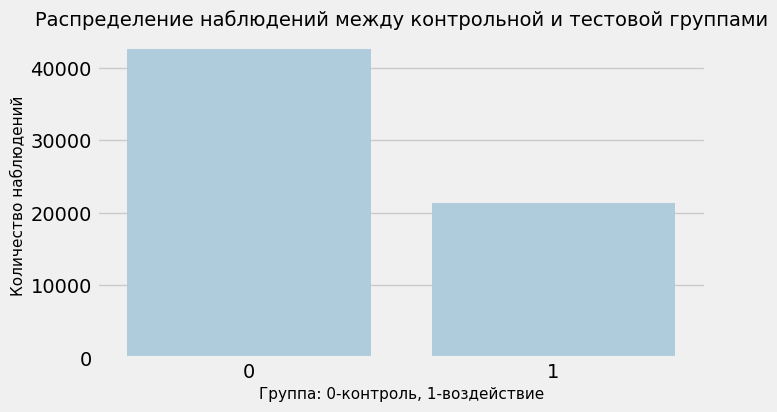

In [30]:
# создаём визуализацию размера экспериментальных групп
plt.figure(figsize=(7, 4))
sns.countplot(
    data=data,
    x="treatment"
)
plt.title("Распределение наблюдений между контрольной и тестовой группами", fontsize=14)
plt.xlabel("Группа: 0-контроль, 1-воздействие", fontsize=11)
plt.ylabel("Количество наблюдений", fontsize=11)
plt.show()

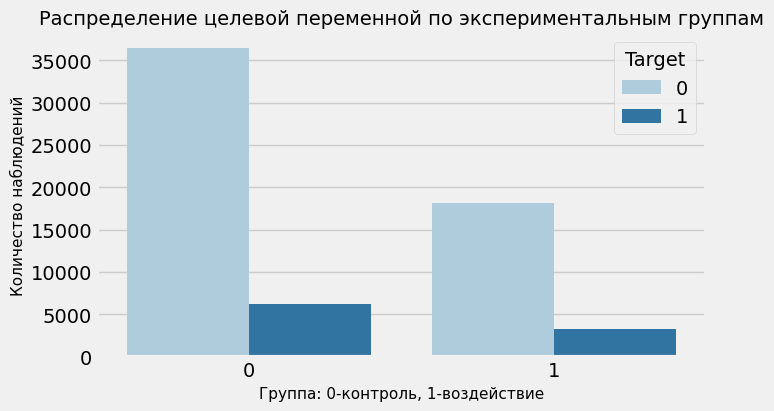

In [29]:
# создаём визуализацию распределения таргета по экспериментальным группам
plt.figure(figsize=(7, 4))
sns.countplot(
    data=data,
    x="treatment",
    hue="target"
)
plt.title("Распределение целевой переменной по экспериментальным группам", fontsize=14)
plt.xlabel("Группа: 0-контроль, 1-воздействие", fontsize=11)
plt.ylabel("Количество наблюдений", fontsize=11)
plt.legend(title="Target")
plt.show()

Контрольная группа содержит 42613 наблюдений, а группа воздействия 21387, то есть выборка распределена между группами примерно в соотношении 2:1. Такая несбалансированность по размеру групп допустима, поскольку обе группы достаточно велики для дальнейшего анализа. Доля положительного таргета в контрольной группе составляет 14.4%, а в группе воздействия 15.1%.

Таким образом, в группе клиентов, получивших промокод, наблюдается небольшое увеличение конверсии примерно на 0.7 процентного пункта. Однако на данном этапе это только наблюдаемое различие: его статистическую значимость необходимо проверить отдельно в следующей главе.

Проверим, насколько контрольная и тестовая группы сопоставимы по основным исходным признакам. Это позволит убедиться, что наблюдаемая разница в конверсии не сопровождается выраженными различиями в характеристиках клиентов между группами.

In [15]:
# создаём список признаков для проверки сопоставимости групп
balance_features = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
]

In [19]:
# рассчитываем средние значения признаков отдельно для контрольной и тестовой групп
group_balance = (
    data.groupby("treatment")[balance_features]
    .mean()
    .T
    .rename(columns={0: "Контроль", 1: "Воздействие"}))

In [20]:
# рассчитываем абсолютную разницу между средними значениями групп
group_balance["Разница"] = (group_balance["Воздействие"] - group_balance["Контроль"])

In [21]:
# выводим таблицу для сравнения групп
display(group_balance)

treatment,Контроль,Воздействие,Разница
recency,5.762,5.768,0.006
history_segment,1.480,1.486,0.006
history,241.859,242.537,0.677
mens,0.552,0.549,-0.003
womens,0.550,0.550,0.001
zip_code,0.748,0.749,0.000
newbie,0.502,0.503,0.002
channel,1.321,1.317,-0.004


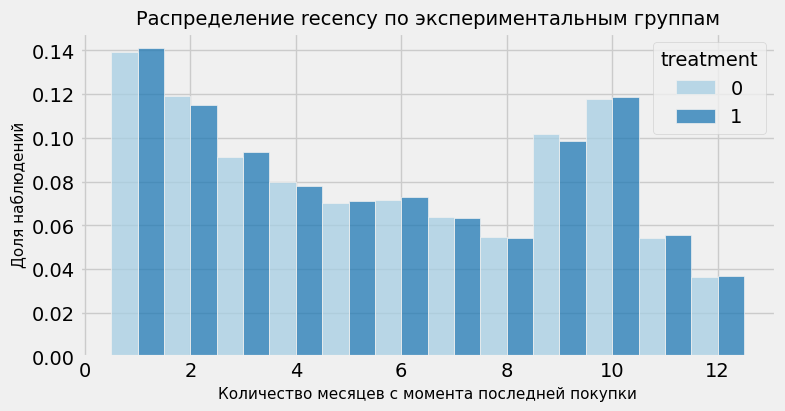

In [26]:
# строим распределение recency по экспериментальным группам
plt.figure(figsize=(8, 4))
sns.histplot(
    data=data,
    x="recency",
    hue="treatment",
    discrete=True,
    stat="probability",
    common_norm=False,
    multiple="dodge")
plt.title("Распределение recency по экспериментальным группам", fontsize=14)
plt.xlabel("Количество месяцев с момента последней покупки", fontsize=11)
plt.ylabel("Доля наблюдений", fontsize=11)
plt.show()

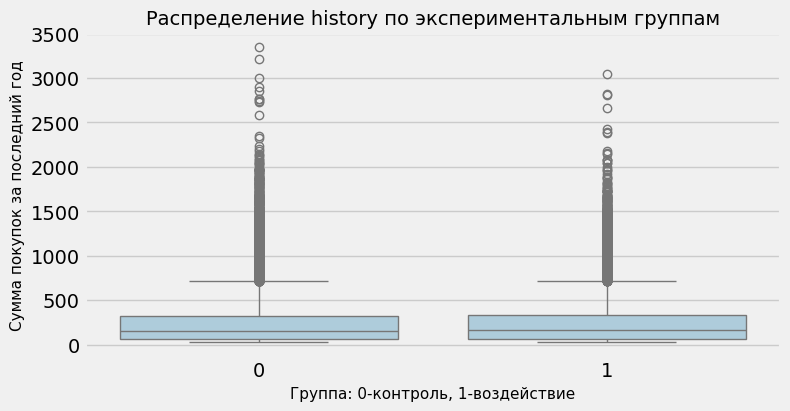

In [25]:
# строим распределение history по экспериментальным группам
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=data,
    x="treatment",
    y="history")
plt.title("Распределение history по экспериментальным группам", fontsize=14)
plt.xlabel("Группа: 0-контроль, 1-воздействие", fontsize=11)
plt.ylabel("Сумма покупок за последний год", fontsize=11)
plt.show()

Контрольная и тестовая группы хорошо сопоставимы по исходным признакам: средние значения практически не отличаются друг от друга, а распределения `recency` и `history` визуально очень похожи. Выраженных систематических различий между группами не наблюдается, поэтому дальнейшее сравнение конверсии между ними выглядит вполне корректным. При этом признак `history` в обеих группах имеет заметную правостороннюю асимметрию и большое количество высоких значений, что стоит учитывать при дальнейшем анализе и возможном создании новых признаков (feature engineering).

<div style="border:solid lightblue 3px; padding: 20px">

По результатам EDA видно, что датасет имеет хорошее качество: пропуски и некорректные категории отсутствуют. Контрольная и тестовая группы различаются по размеру примерно в соотношении 2:1, однако обе группы достаточно велики для дальнейшего анализа.

Конверсия в контрольной группе составляет 14.4%, а в группе воздействия 15.1%, то есть наблюдается небольшой положительный эффект промокода примерно в 0.7 процентного пункта. При этом контрольная и тестовая группы хорошо сопоставимы по исходным признакам: средние значения и распределения основных характеристик практически совпадают.

Признак `history` имеет выраженную правостороннюю асимметрию и большое количество высоких значений, что стоит учитывать при дальнейшем моделировании и возможном feature engineering. Наблюдаемое различие в конверсии пока нельзя считать статистически значимым без отдельной проверки гипотез, поэтому переходим к проверке на статистическую значимость.

### Проверка на статистическую значимость

Проверим, является ли различие в конверсии между контрольной и тестовой группами статистически значимым. Поскольку целевая переменная `target` бинарная, а нас интересует сравнение долей успешной конверсии в двух независимых группах, используем двухвыборочный z-тест для пропорций.

Сформулируем гипотезы:

- **H₀:** доля положительного таргета в контрольной и тестовой группах одинакова.
- **H₁:** доля положительного таргета в контрольной и тестовой группах различается.

Уровень статистической значимости примем равным `alpha = 0.05`.

In [32]:
# задаём уровень статистической значимости
alpha = 0.05

In [33]:
# выделяем контрольную и тестовую группы
control_group = data[data["treatment"] == 0]["target"]
treatment_group = data[data["treatment"] == 1]["target"]

In [34]:
# рассчитываем средние значения и стандартные отклонения таргета по группам
group_stats = pd.DataFrame({
    "Группа": ["Контроль", "Воздействие"],
    "Среднее": [control_group.mean(), treatment_group.mean()],
    "Стандартное отклонение": [control_group.std(), treatment_group.std()],
    "Количество наблюдений": [len(control_group), len(treatment_group)],
})

In [35]:
# выводим описательные статистики по группам
display(group_stats)

,Группа,Среднее,Стандартное отклонение,Количество наблюдений
0,Контроль,0.144,0.352,42613
1,Воздействие,0.151,0.358,21387


In [36]:
# считаем число положительных исходов в каждой группе
successes = np.array([
    control_group.sum(),
    treatment_group.sum()
])

In [37]:
# считаем общее число наблюдений в каждой группе
nobs = np.array([
    len(control_group),
    len(treatment_group)
])

In [38]:
# выполняем двухвыборочный z-тест для пропорций
z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=nobs,
    alternative="two-sided"
)

In [39]:
# выводим результаты теста
print(f"z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.3f}")
print(f"Уровень значимости: {alpha}")

Z-статистика: -2.339
p-value: 0.019
Уровень значимости: 0.05


Полученное значение `p-value = 0.019` меньше выбранного уровня статистической значимости `alpha = 0.05`. Поэтому нулевая гипотеза об одинаковой доле положительного таргета в контрольной и тестовой группах отвергается.

Для визуального сравнения между группами построим график.

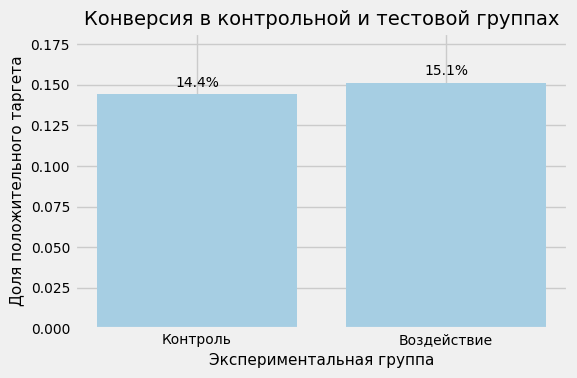

In [55]:
# рассчитываем конверсию по экспериментальным группам
conversion_rates = (
    data.groupby("treatment")["target"]
    .mean()
    .sort_index())

# создаём фигуру и оси
fig, ax = plt.subplots(figsize=(6, 4))

# строим столбчатую диаграмму
bars = ax.bar(
    ["Контроль", "Воздействие"],
    conversion_rates.values)

# добавляем значения конверсии над столбцами
ax.bar_label(
    bars,
    labels=[f"{value:.1%}" for value in conversion_rates.values],
    padding=3,
    fontsize=10)

# оформляем график
ax.set_title(
    "Конверсия в контрольной и тестовой группах",
    fontsize=14)
ax.set_xlabel("Экспериментальная группа", fontsize=11)
ax.set_ylabel("Доля положительного таргета", fontsize=11)
ax.set_ylim(0, conversion_rates.max() * 1.20)
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

<div style="border:solid lightblue 3px; padding: 20px">

Таким образом, различие в конверсии между группами статистически значимо: в группе воздействия конверсия выше 15.1% против 14.4% в контрольной группе. При этом абсолютный эффект невелик и составляет около 0.7 процентного пункта, что дополнительно обосновывает необходимость uplift-моделирования для поиска пользователей, на которых воздействие работает наиболее эффективно.

### Построение корреляций

Сделайте вывод о корреляциях признаков друг с другом и таргетом в этой ячейке

**Вывод**

<div style="border:solid lightblue 3px; padding: 20px">
    
Итак,

## Этап 3

Обоснуйте выбор конкретной uplift модели в данной ячейке

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

### Обучение выбранного бейзлайна

### Расчет метрик для выбранного бейзлайна на тестовой выборке

# Обучение 2 моделей 

### Обучение модели 1

### Получение метрик по модели 1

### Обучение модели 2

### Получение метрик по модели 2

Проинтерпретируйте полученные результаты и обоснуйте выбор 1 модели в этой ячейке

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [5]:
from optuna import create_study
from sklift.metrics import uplift_at_k

def objective(trial):
    # Дополните код для подбора гиперпараметров

    uplift_at_30 = uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


[I 2026-09-15 09:15:01,496] A new study created in memory with name: no-name-f03a887f-d940-402e-8a64-f0194ec38895
[W 2026-09-15 09:15:01,498] Trial 0 failed with parameters: {} because of the following error: NameError("name 'y_test' is not defined").
Traceback (most recent call last):
  File "/home/mle-user/mle_projects/mle-project-sprint-5-v001/uplift_project_env/lib/python3.10/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_3679/2685810187.py", line 7, in objective
    uplift_at_30 = uplift_at_k(y_test, uplift_pred, treatment_test, k=0.3, strategy='overall')
NameError: name 'y_test' is not defined
[W 2026-09-15 09:15:01,502] Trial 0 failed with value None.


NameError: name 'y_test' is not defined

## Этап 2

### Визуализация результатов

In [ ]:
from utils import custom_uplift_by_percentile

В данной ячейке сделайте вывод о качестве работы модели и проинтерпретируйте график `uplift by percentile` 

# Этап 3

In [ ]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [ ]:
model = UpliftModelInference(model= # ваш код,
                             feature_names= # ваш код)

In [ ]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [ ]:
# проверка работы класса
model.predict(test_data)